# Impact des coûts sur le SMA — même graphique qu'AAPL, pour les 7 autres titres

On reprend **exactement** le graphique du notebook 04 (courbes d'équité sous quatre scénarios de coûts : sans coût, 1+2, 5+5, 10+10 bps), mais titre par titre, **une figure séparée par action**.

In [1]:
import sys, queue; sys.path.insert(0, "../src")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from data import HistoricCSVDataHandler
from strategy import MovingAverageCrossStrategy
from portfolio import Portfolio
from execution import SimulatedExecutionHandler
from backtest import run_backtest

prices = pd.read_csv("../data/adj_close.csv", index_col=0, parse_dates=True)

def run_sma(symbol, short=50, long=200, commission_bps=0.0, slippage_bps=0.0,
            initial_capital=100_000.0, target_pct=0.95):
    ev = queue.Queue()
    d = HistoricCSVDataHandler(ev, prices, [symbol]); d.events = ev
    s = MovingAverageCrossStrategy(d, ev, [symbol], short, long)
    p = Portfolio(d, ev, [symbol], prices.index[0], initial_capital, target_pct)
    x = SimulatedExecutionHandler(d, ev, commission_bps, slippage_bps)
    return run_backtest(d, s, p, x)

scenarios = {"Sans coût": (0, 0), "1 bps + 2 bps": (1, 2),
             "5 bps + 5 bps": (5, 5), "10 bps + 10 bps": (10, 10)}

def graphe_couts(symbol):
    """Même graphique que pour AAPL (notebook 04), pour un titre donné."""
    curves = {}
    for label, (cb, sb) in scenarios.items():
        ec = run_sma(symbol, 50, 200, cb, sb)
        curves[label] = ec["equity"]
    fig, ax = plt.subplots(figsize=(12, 5))
    for label, eq in curves.items():
        (eq / eq.iloc[0]).plot(ax=ax, label=label, lw=1.4)
    ax.set_title(f"{symbol} — SMA 50/200 : l'impact des coûts est marginal (faible turnover)")
    ax.set_ylabel("Équité (base 1)"); ax.legend()
    plt.tight_layout(); plt.show()

## MSFT

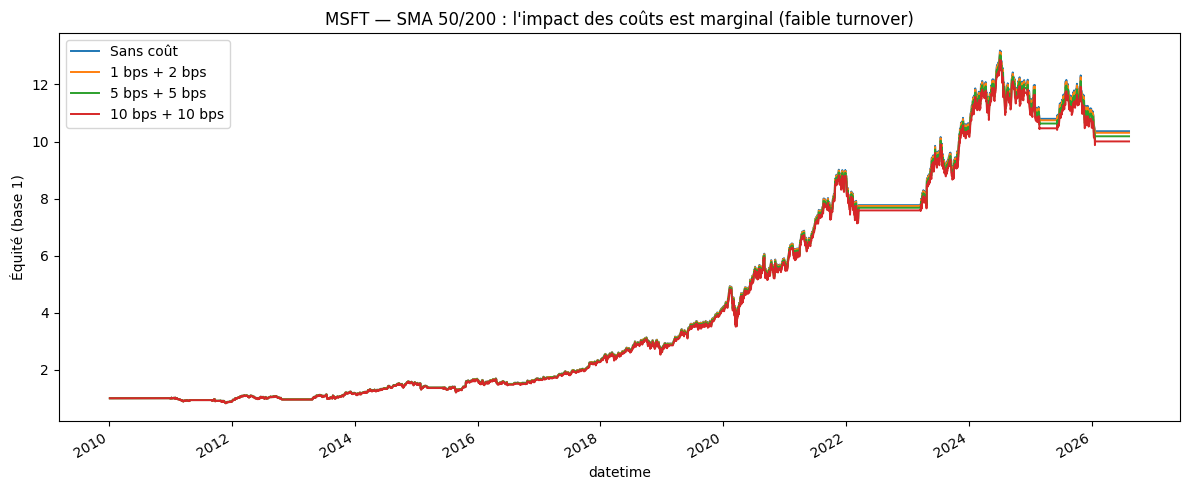

In [2]:
graphe_couts("MSFT")

## NVDA

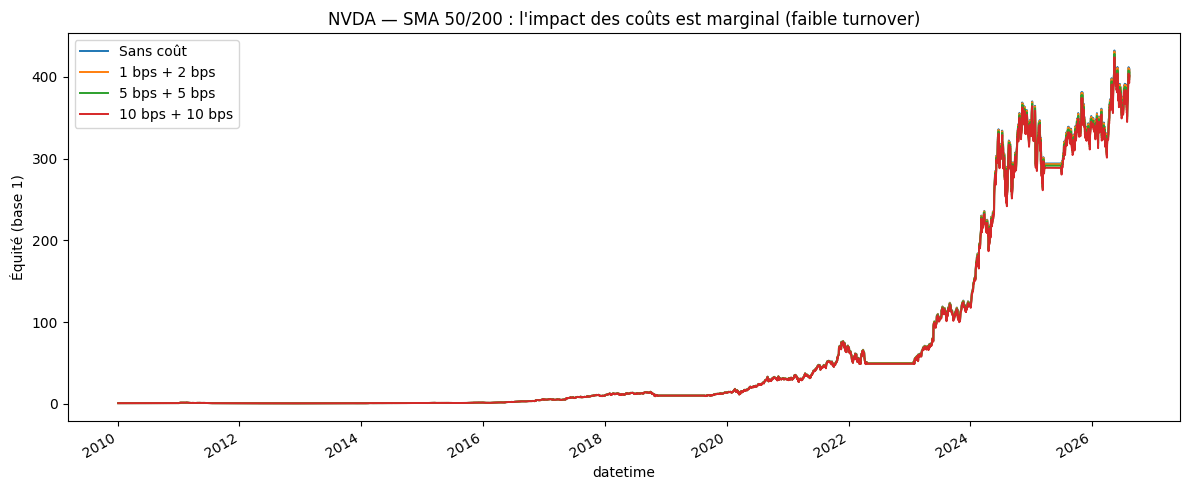

In [3]:
graphe_couts("NVDA")

## AMZN

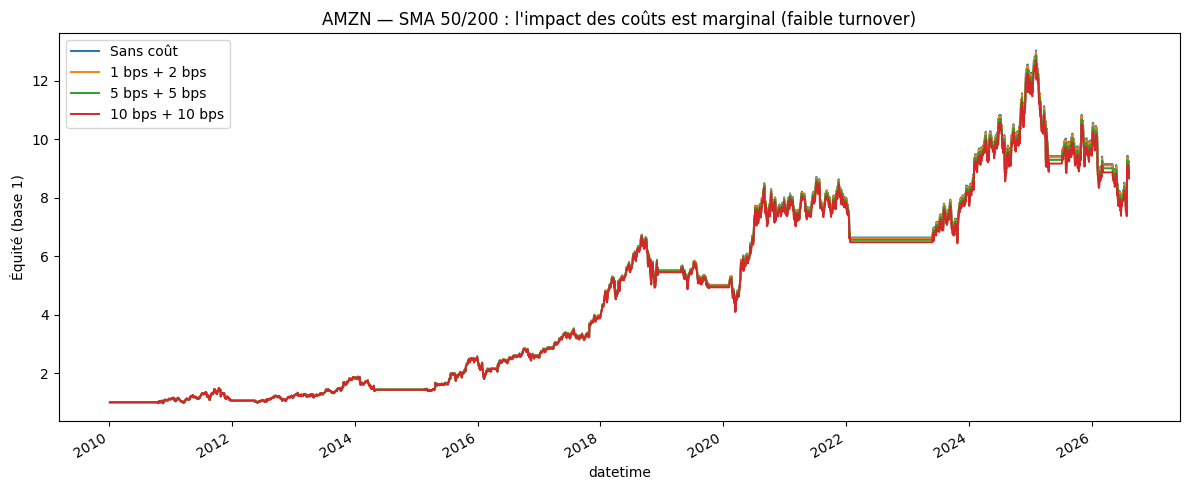

In [4]:
graphe_couts("AMZN")

## JPM

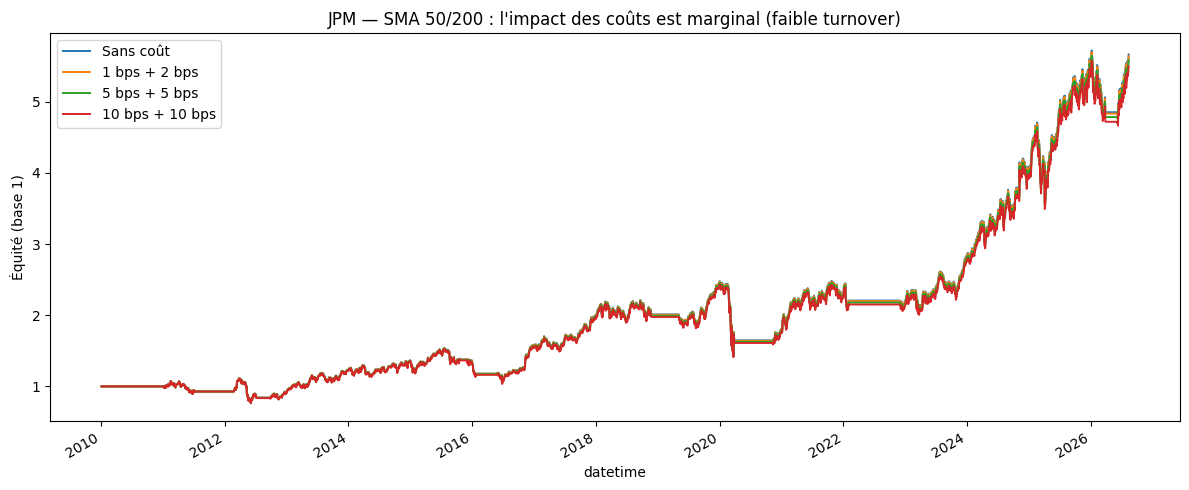

In [5]:
graphe_couts("JPM")

## XOM

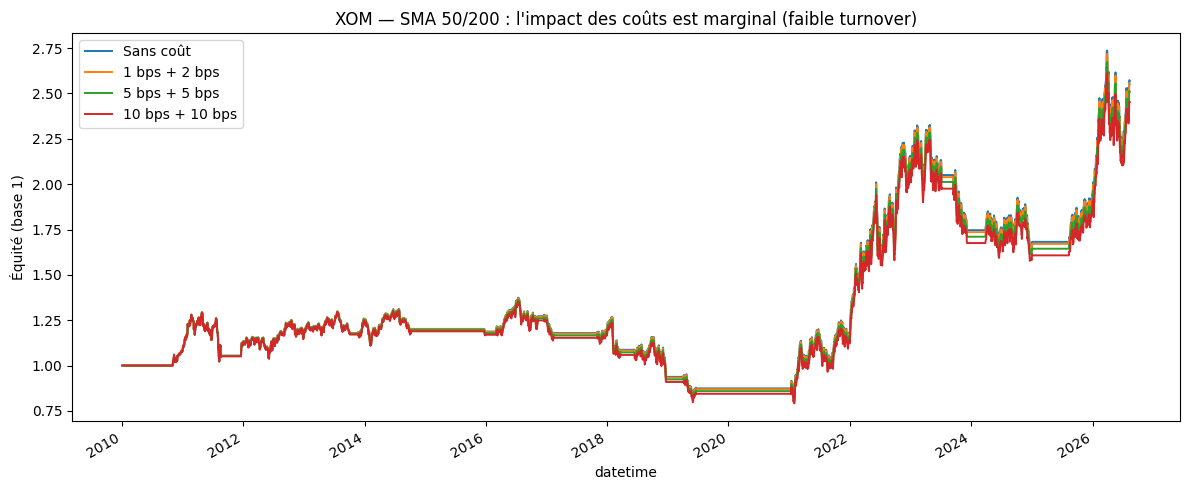

In [6]:
graphe_couts("XOM")

## JNJ

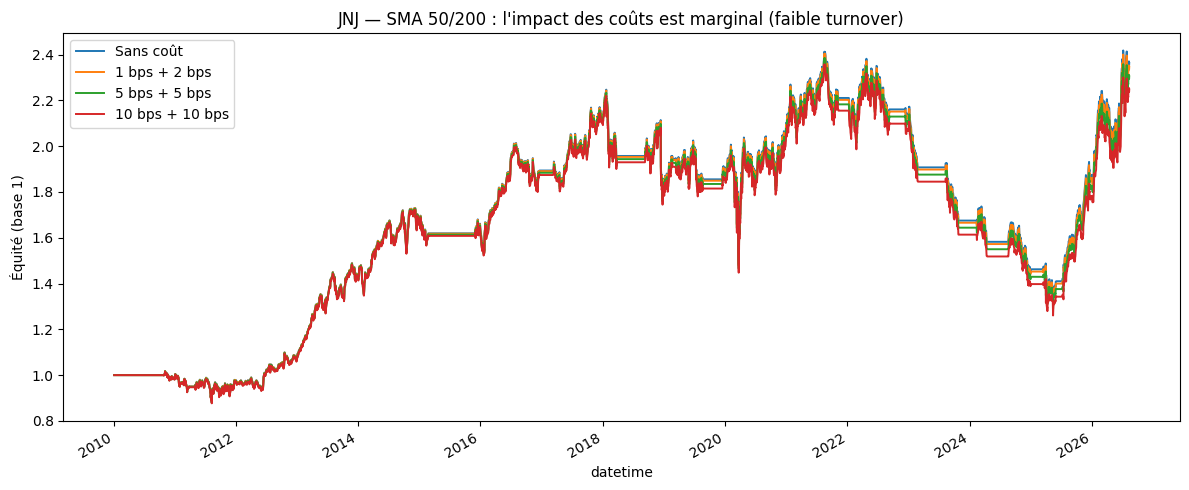

In [7]:
graphe_couts("JNJ")

## PG

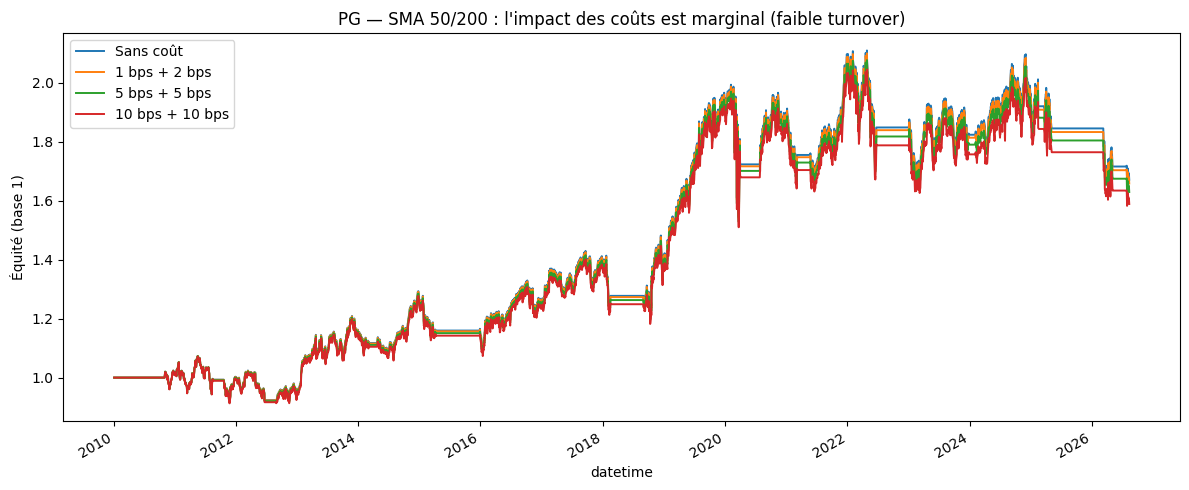

In [8]:
graphe_couts("PG")